## Variance in Linear Regression

The goal of this notebook is to show how various levels of variance in the dataset can affect the performance of a linear regression model trained with SGD.

In [11]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

In [12]:
"""Generate dataset helper"""

import numpy as np

MIN = -7
MAX = 7
SEED = 777

def generate_dataset(size: int, sample_size: int, noise_upto: float) -> np.ndarray:
    rng = np.random.default_rng(SEED)
    x = rng.uniform(MIN, MAX, sample_size)
    y = f(x)
    y_noise = None

    datasets: list[np.ndarray] = []

    for noise in np.linspace(0, noise_upto, size):
        y_noise = y + rng.standard_normal(x.shape[0]) * noise
        sample = np.stack([x, y_noise]).T

        datasets.append(sample)

    return np.stack(datasets[:])

## How data are build
 
The datasets builds with `generate_dataset` function has structuraly higher variance along `axis=0`.
Variance increases is computed generating an array of equally spaced values between `0` and `noise_upto` and adding it to the `y` values of the dataset. The higher the `noise_upto` value, the higher the variance in the dataset.

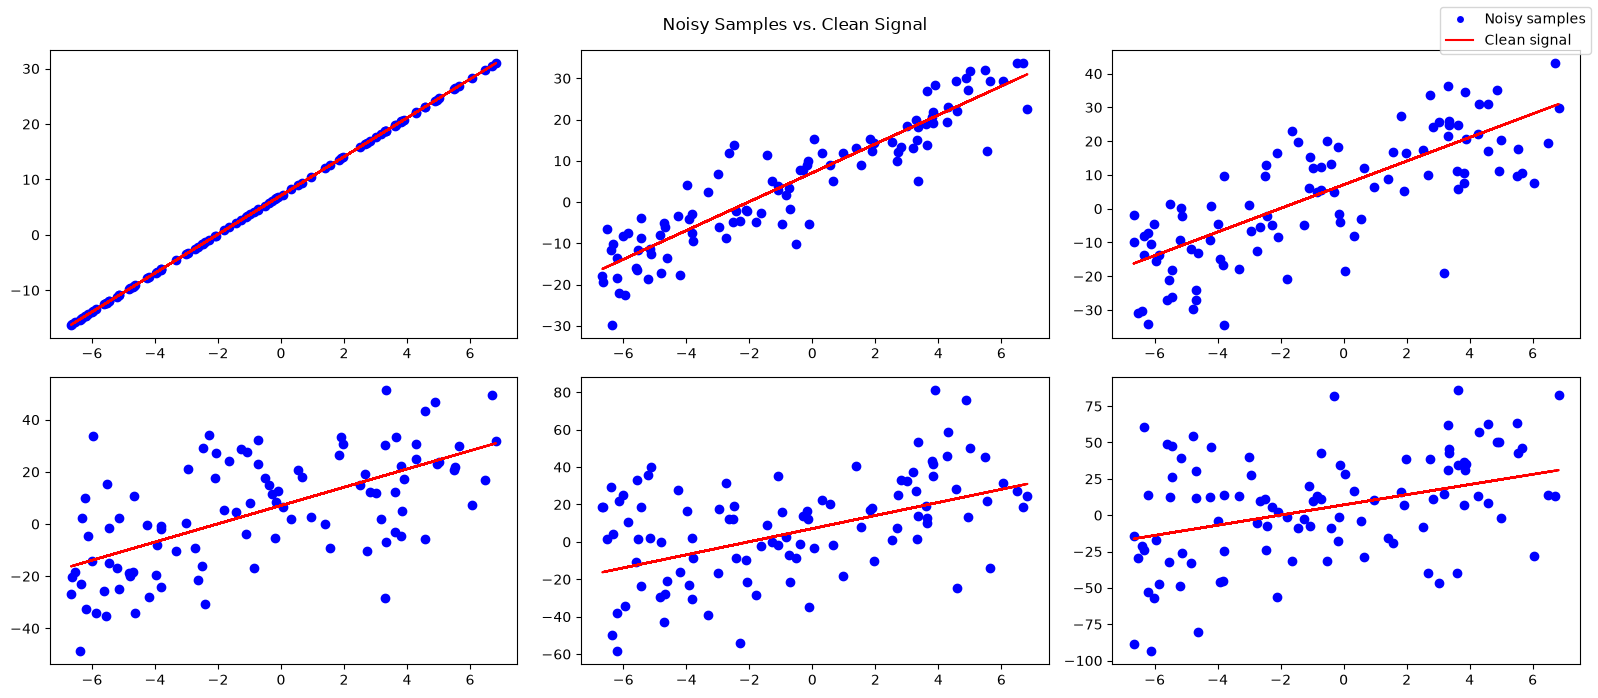

In [13]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from examples.helpers.graph import generate_axs, plot_dataset, scatter_dataset

DATASETS_SIZE = 6
SAMPLE_SIZE = 100

X = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=30)
X_clean = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0)

fig, axs = generate_axs(X.shape[0])
scatter_dataset(X, fig, axs)
plot_dataset(X_clean, fig, axs)

fig.suptitle("Noisy Samples vs. Clean Signal")
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Noisy samples'),
    Line2D([0], [0], color='red', label='Clean signal'),
], loc='upper right')

fig.tight_layout()
plt.show()

## Training the models

First of all, we need to instanciate a model for each dataset with different variance levels. Then, we will train each model using the `fit_models` function.

In [14]:
from core.training import Trainer
from examples.helpers.train import create_trainer, fit_models, split_dataset


EPOCHS = 500
EVAL_STEP = 10
BATCH_SIZE = 16
MAX_LR, MIN_LR = 1e-2, 1e-4


trainers: list[Trainer] = []
X_tr, X_te = split_dataset(X, split_ratio=0.9, axis=1)

for i in range(DATASETS_SIZE):
    trainer = create_trainer(X.shape[2]-1, X.shape[2]-1, MIN_LR, MAX_LR, EPOCHS)
    trainers.append(trainer)

fit_models(trainers, X_tr, X_te, EPOCHS, EVAL_STEP, BATCH_SIZE)

## Loss history

Finally, we will plot the loss history of each model to visualize how variance affects the training process. The training loss will be plotted in blue, while the evaluation loss will be plotted in red.

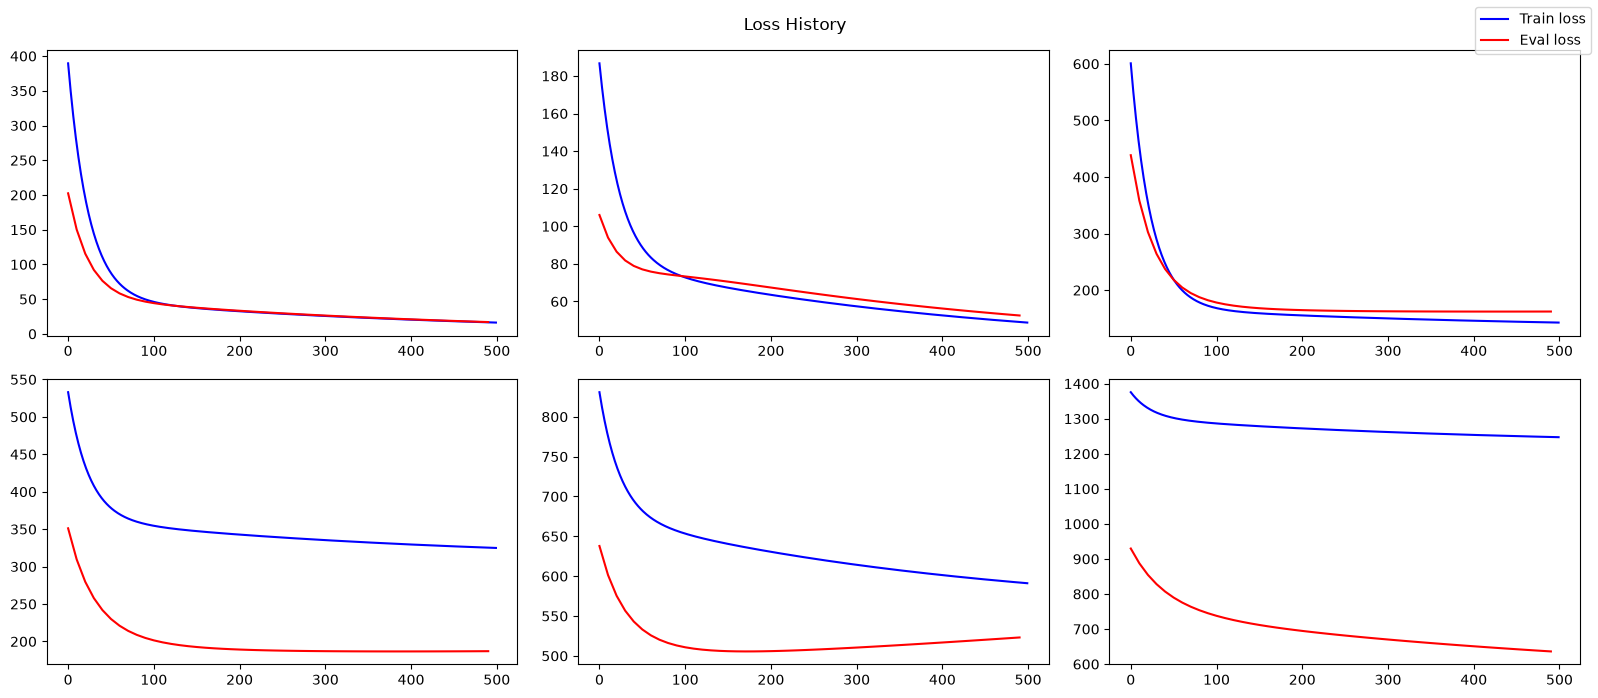

In [15]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from examples.helpers.graph import generate_axs, plot_dataset

fig, axs = generate_axs(len(trainers))

train_loss_history = []
eval_loss_history = []

for trainer in trainers:
    train_loss_history.append([range(EPOCHS), trainer.train_loss])
    eval_loss_history.append([range(0, EPOCHS, EVAL_STEP), trainer.eval_loss])

train_loss_history = np.array(train_loss_history)
eval_loss_history = np.array(eval_loss_history)

plot_dataset(train_loss_history, fig, axs, color='blue', axis=-1)
plot_dataset(eval_loss_history, fig, axs, color='red', axis=-1)

fig.suptitle("Loss History")
fig.legend(handles=[
    Line2D([0], [0], color='blue', label='Train loss'),
    Line2D([0], [0], color='red', label='Eval loss'),
], loc='upper right')

fig.tight_layout()
plt.show()

In [16]:
from core.layers import Sequential


def get_model_param(model: Sequential) -> np.ndarray:
    param = model.parameters
    weights, bias = param
    bias = bias.reshape(-1, 1)

    param = np.array([weights, bias])
    return param

def get_models_params(models: list[Sequential]) -> np.ndarray:
    params = []
    for model in models:
        local_param = get_model_param(model)
        params.append(local_param)

    return np.array(params)

## Weights Interpretation

The weights of each model will be plotted in a histogram to visualize how variance affects the learned weights. The weights of each model will be plotted in blue, while the true weights will be plotted in red.

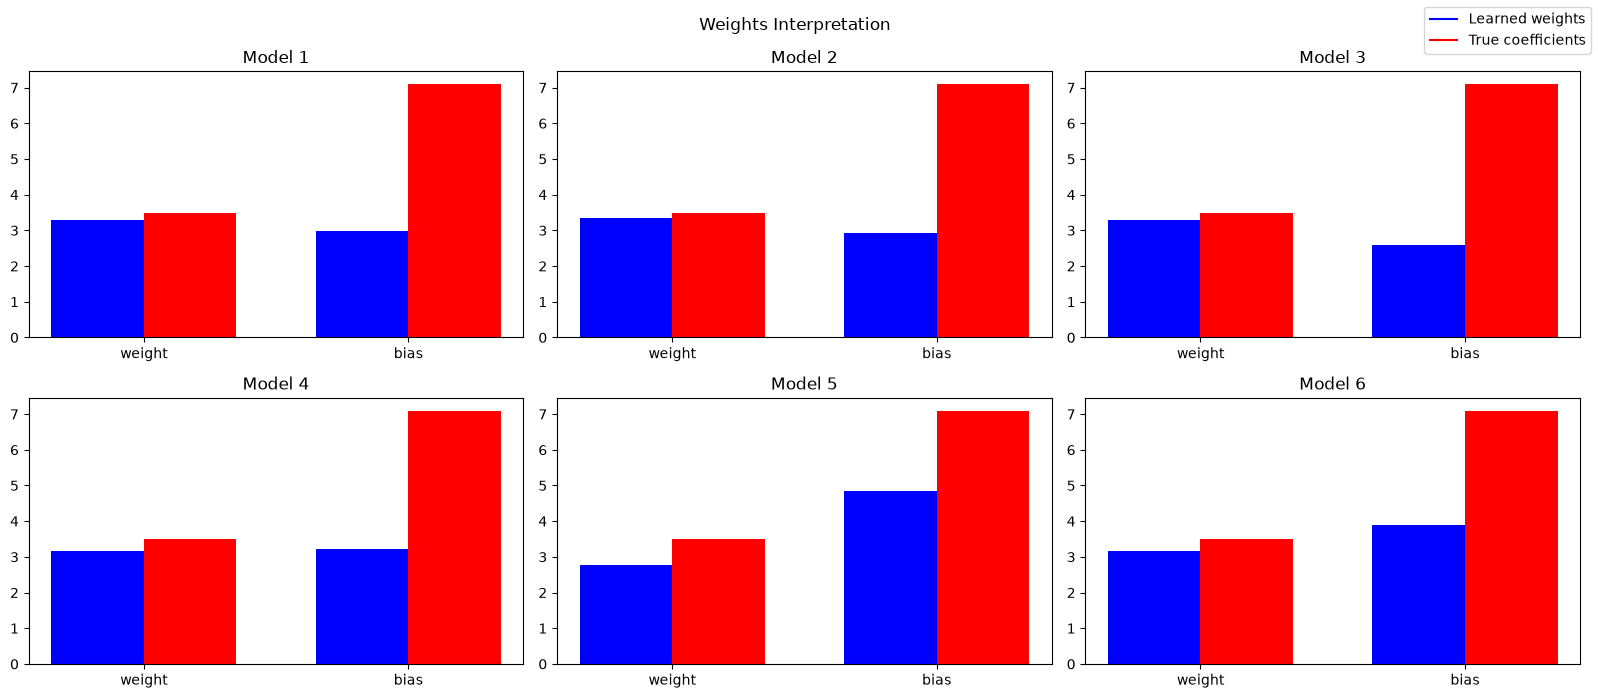

In [17]:
from matplotlib.lines import Line2D
from examples.helpers.graph import bar_dataset

fig, axs = generate_axs(len(trainers))

models_params = get_models_params([trainer.model for trainer in trainers])

bar_dataset(models_params, coefs, fig, axs)

fig.suptitle("Weights Interpretation")
fig.legend(handles=[
    Line2D([0], [0], color='blue', label='Learned weights'),
    Line2D([0], [0], color='red', label='True coefficients'),
], loc='upper right')

fig.tight_layout()
plt.show()
